In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nFirst 5 Rows:")
display(X.head())

Dataset Shape: (20640, 8)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


In [4]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully!")
print("Number of predictions:", len(linear_predictions))

Linear Regression trained successfully!
Number of predictions: 4128


In [5]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

print("Linear Regression Coefficients:")
display(coefficients)

print("Intercept:", linear_model.intercept_)

Linear Regression Coefficients:


,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


Intercept: -37.02327770606416


In [6]:
mse = mean_squared_error(y_test, linear_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, linear_predictions)
r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Evaluation")
print("-----------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

Linear Regression Evaluation
-----------------------------
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
MAE : 0.5332001304956555
R²  : 0.575787706032451


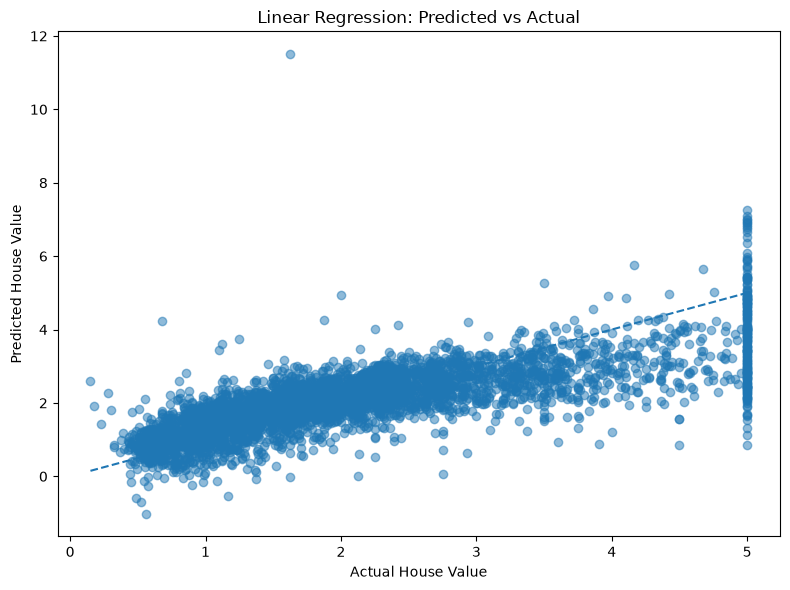

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_predictions, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression: Predicted vs Actual")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

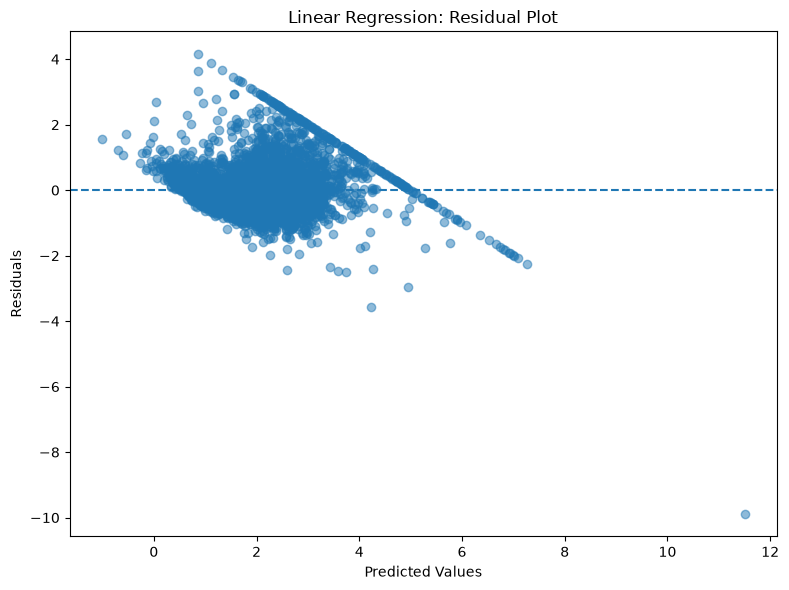

In [8]:
residuals = y_test - linear_predictions

plt.figure(figsize=(8, 6))

plt.scatter(linear_predictions, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")

plt.tight_layout()
plt.show()

In [9]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.01, max_iter=10000))
])

ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)
lasso_predictions = lasso_model.predict(X_test)

print("Ridge Regression trained successfully!")
print("Lasso Regression trained successfully!")

Ridge Regression trained successfully!
Lasso Regression trained successfully!


In [10]:
def evaluate_model(name, y_true, predictions):
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, predictions)
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


results = [
    evaluate_model("Linear Regression", y_test, linear_predictions),
    evaluate_model("Ridge Regression", y_test, ridge_predictions),
    evaluate_model("Lasso Regression", y_test, lasso_predictions)
]

results_df = pd.DataFrame(results)

print("MODEL COMPARISON")
display(results_df)

MODEL COMPARISON


,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.555892,0.745581,0.533200,0.575788
1,Ridge Regression,0.555855,0.745557,0.533193,0.575816
2,Lasso Regression,0.548255,0.740442,0.535326,0.581615


In [11]:
best_model = results_df.loc[results_df["R2"].idxmax()]

print("BEST MODEL")
print("===========")
print("Model:", best_model["Model"])
print("R²:", best_model["R2"])
print("RMSE:", best_model["RMSE"])
print("MAE:", best_model["MAE"])

BEST MODEL
Model: Lasso Regression
R²: 0.5816154300698727
RMSE: 0.7404423656125414
MAE: 0.5353261423609053


# W3D2: Linear Regression, Ridge and Lasso Regression

## Objective

This project demonstrates regression using a real-world dataset.

### Tasks Completed
- Train Linear Regression on the California Housing dataset
- Print Linear Regression coefficients
- Evaluate the model using MSE, RMSE, MAE and R²
- Plot Predicted vs Actual values
- Plot residuals
- Train Ridge Regression
- Train Lasso Regression
- Compare all three models
- Identify the best performing model

## Conclusion

Linear Regression, Ridge Regression and Lasso Regression were trained and evaluated using the California Housing dataset.

The models were compared using MSE, RMSE, MAE and R².

A higher R² and lower error values indicate better model performance. Regularization techniques such as Ridge and Lasso help control model complexity and can improve generalization.

The model with the highest R² value is considered the best performing model for this comparison.